In [16]:
import torch
import os
from pathlib import Path

# NOTE: change this to data dir as appropriate
DATA_PATH = os.path.abspath("../midi/data")

acts = torch.load(Path(DATA_PATH) / "activations" / "000.pt")

print("Saved activations:")
for layer, tensors in list(acts.items())[:10]:
    print(f"{layer:>35} | {len(tensors):>6} calls | {tensors[0].shape}")
print(f"... ({len(acts)} total layers)")

Saved activations:
     decoder.model.decoder.layers.0 |    256 calls | torch.Size([2, 1, 1024])
     decoder.model.decoder.layers.1 |    256 calls | torch.Size([2, 1, 1024])
     decoder.model.decoder.layers.2 |    256 calls | torch.Size([2, 1, 1024])
     decoder.model.decoder.layers.3 |    256 calls | torch.Size([2, 1, 1024])
     decoder.model.decoder.layers.4 |    256 calls | torch.Size([2, 1, 1024])
     decoder.model.decoder.layers.5 |    256 calls | torch.Size([2, 1, 1024])
     decoder.model.decoder.layers.6 |    256 calls | torch.Size([2, 1, 1024])
     decoder.model.decoder.layers.7 |    256 calls | torch.Size([2, 1, 1024])
     decoder.model.decoder.layers.8 |    256 calls | torch.Size([2, 1, 1024])
     decoder.model.decoder.layers.9 |    256 calls | torch.Size([2, 1, 1024])
... (24 total layers)


In [17]:
import numpy as np

layer = "decoder.model.decoder.layers.0"
layer_acts = torch.cat(acts[layer], dim=1)
print(layer_acts.shape)
layer_np = layer_acts.numpy()

torch.Size([2, 256, 1024])


In [18]:
print(layer_acts.mean().item(), layer_acts.std().item())

0.393604576587677 0.38253477215766907


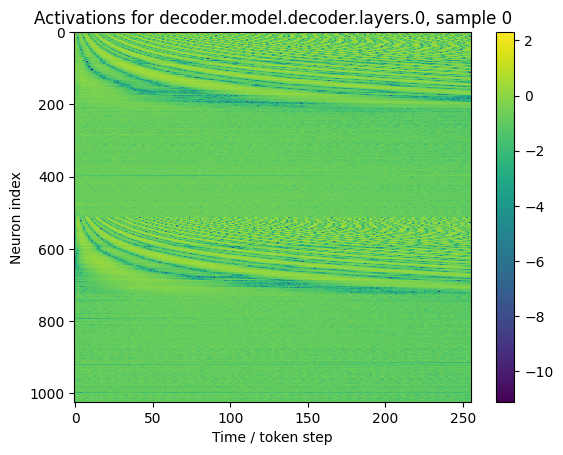

In [35]:
import matplotlib.pyplot as plt

layer = "decoder.model.decoder.layers.0"
layer_acts = torch.cat(acts[layer], dim=1)  # [batch, time, d_model]
one = layer_acts[0]                         # [time, d_model]

plt.imshow(np.log(np.abs(one.T)), aspect="auto", interpolation="nearest")
plt.xlabel("Time / token step")
plt.ylabel("Neuron index")
plt.title(f"Activations for {layer}, sample 0")
plt.colorbar()
plt.show()